In [37]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

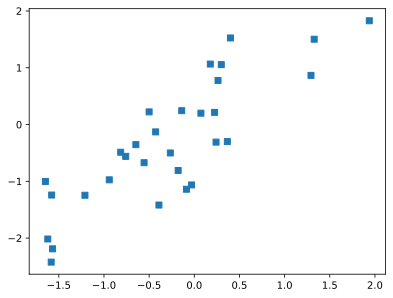

In [38]:
# create data

N = 30
x = torch.randn(N,1)
y = x + torch.randn(N,1)/2

# and plot
plt.plot(x,y,'s')
plt.show()

In [39]:
# Building model
model = nn.Sequential(
    nn.Linear(1,1),  # input layer
    nn.ReLU(),       # activation function
    nn.Linear(1,1)   # output layer
    )

model

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [40]:
# Meta parameters
leaningr_rate = 0.05

# loss function
loss_fun = nn.MSELoss()

# optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=leaningr_rate)

In [41]:
# train the model
EPOCHS = 500
losses = torch.zeros(EPOCHS)


## Train the model!
for epochi in range(EPOCHS):

  # forward pass
  y_predoct = model(x)

  # compute loss
  loss = loss_fun(y_predoct,y)
  losses[epochi] = loss

  # backprop
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

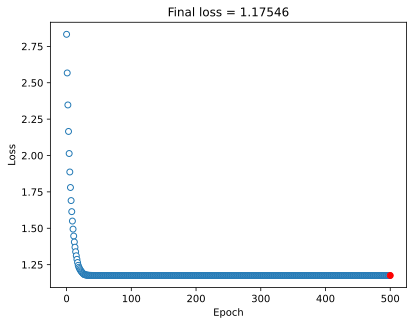

In [42]:
# show the losses

# manually compute losses
# final forward pass
predictions = model(x)

# final loss (MSE)
testloss = (predictions-y).pow(2).mean()

plt.plot(losses.detach(),'o',markerfacecolor='w',linewidth=.1)
plt.plot(EPOCHS,testloss.detach(),'ro')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final loss = %g' %testloss.item())
plt.show()